# Laboratorio #3

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab3)
- [Data](https://drive.google.com/drive/folders/1DZaL352Xo1kNSpZjXH-HmXbgpbyhrx6E?usp=drive_link)

## Análisis exploratorio

In [ ]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from collections import Counter
from PIL import Image

### Constantes

In [ ]:
BASE_DIR = "./data_original/train"
IMAGE_DIR = "./images"
REPORT_DIR = "./reports"
MODALITIES = ['m0', 'm1', 'm2', 'm3', 'm4']
DO_EA = False

os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

reportPath = os.path.join(REPORT_DIR, "analisis_exploratorio.txt")

### Generación de reportes

In [ ]:
def writeToReport(text, printAlso=True):
    with open(reportPath, "a", encoding="utf-8") as f:
        f.write(text + "\n")
    if printAlso:
        print(text)

In [ ]:
def resetReport():
    with open(reportPath, "w", encoding="utf-8") as f:
        f.write("ANÁLISIS EXPLORATORIO DATASET IMAGENES\n\n")

In [ ]:
def checkImageResolution(modality='m0'):
    path = os.path.join(BASE_DIR, modality)
    imgPath = os.path.join(path, random.choice(os.listdir(path)))
    img = Image.open(imgPath)
    size = img.size
    writeToReport(f"Ejemplo de resolución de imágen de {modality}: {size}")
    return size

In [ ]:
def countDigitsPerModality():
    writeToReport("Distribución de imágenes de dígitos por modalidad:\n")
    for modality in MODALITIES:
        path = os.path.join(BASE_DIR, modality)
        files = os.listdir(path)
        digits = [f.split('.')[-2] for f in files]
        count = Counter(digits)
        writeToReport(f"{modality}:")
        for d in sorted(count):
            writeToReport(f"  Dígito {d}: {count[d]} imágenes")
        writeToReport("")

In [ ]:
def countImagesPerModality():
    writeToReport("Total de imágenes por modo:\n")
    for modality in MODALITIES:
        path = os.path.join(BASE_DIR, modality)
        total = len(os.listdir(path))
        writeToReport(f"{modality}: {total} imágenes")
    writeToReport("")

In [ ]:
def showDigitExamplesPerModality(digit="5", saveImage=False):
    plt.figure(figsize=(15, 6))
    for i, modality in enumerate(MODALITIES):
        modalityPath = os.path.join(BASE_DIR, modality)
        digitImages = [f for f in os.listdir(modalityPath) if f.endswith(f".{digit}.png")]
        if not digitImages:
            continue

        imgFile = random.choice(digitImages)
        imgPath = os.path.join(modalityPath, imgFile)
        img = mpimg.imread(imgPath)

        plt.subplot(1, 5, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"{modality} - {digit}")
        plt.axis("off")

    plt.suptitle(f"Ejemplo del dígito '{digit}' en las modalidades")
    plt.tight_layout()

    if saveImage:
        savePath = os.path.join(IMAGE_DIR, f"digit_{digit}_modalities.png")
        plt.savefig(savePath)
        writeToReport(f"Image saved to: {savePath}")

    plt.show()

In [ ]:
if DO_EA:
    resetReport()
    showDigitExamplesPerModality(digit="2", saveImage=True)
    checkImageResolution(modality="m0")
    countImagesPerModality()
    countDigitsPerModality()

In [ ]:
numberToName = {
    0: "zero",
    1: "one",
    2: "two",
    3: "three",
    4: "four",
    5: "five",
    6: "six",
    7: "seven",
    8: "eight",
    9: "nine",
}

In [ ]:
def showRandomExamples(folder="data/train", samples=9):
    """
    Muestra imágenes aleatorias de distintas clases desde la carpeta dada.
    """
    plt.figure(figsize=(12, 6))
    for i in range(samples):
        number = random.randint(0, 9)
        subfolder = numberToName[number]
        filename = f'{folder}/{subfolder}/m{random.randint(1,4)}-0.{number}.png'
        try:
            image = imread(filename)
            plt.subplot(3, 3, i + 1)
            plt.imshow(image, cmap="gray")
            plt.title(f"{subfolder}")
            plt.axis("off")
        except FileNotFoundError:
            print(f"Imagen no encontrada: {filename}")
    plt.tight_layout()
    plt.show()

In [ ]:
# showRandomExamples()

## Explorando los Datos

### Librerías

In [ ]:
from tensorflow.keras.layers import Rescaling
from keras.utils import image_dataset_from_directory

### Cargar data

In [ ]:
def loadImageDataset(dataDir="data/train", batchSize=32, imageSize=(28, 28), shuffle=True):
    """
    Carga el dataset desde carpetas organizadas por clase usando Keras.
    Retorna un objeto tf.data.Dataset listo para entrenamiento.
    """
    dataset = image_dataset_from_directory(
        dataDir,
        labels='inferred',
        batch_size=batchSize,
        image_size=imageSize,
        shuffle=shuffle
    )
    return dataset

In [ ]:
def loadImageDatasetWithSplit(dataDir="data/train", imageSize=(28, 28), batchSize=32, valSplit=0.2, seed=123):
    train_ds = image_dataset_from_directory(
        dataDir,
        validation_split=valSplit,
        subset="training",
        seed=seed,
        image_size=imageSize,
        batch_size=batchSize
    )
    val_ds = image_dataset_from_directory(
        dataDir,
        validation_split=valSplit,
        subset="validation",
        seed=seed,
        image_size=imageSize,
        batch_size=batchSize
    )
    return train_ds, val_ds

Esta función carga un conjunto de imágenes desde `data/train` y lo divide automáticamente en dos subconjuntos:

- trains_ds
- val_ds


| Parámetro   | Descripción                                                                                        |
| ----------- | -------------------------------------------------------------------------------------------------- |
| `dataDir`   | Ruta a la carpeta raíz donde están las imágenes organizadas por clase. Por defecto: `"data/train"` |
| `imageSize` | Tamaño al que se redimensionan todas las imágenes. Por defecto: `(28, 28)`                         |
| `batchSize` | Cantidad de imágenes que se agrupan en un lote. Por defecto: `32`                                  |
| `valSplit`  | Porcentaje del conjunto que se reservará como validación. Por defecto: `0.2` (20%)                 |
| `seed`      | Semilla aleatoria que asegura que la división sea reproducible.                                    |

In [ ]:
def normalizeDataset(dataset):
    normalization_layer = Rescaling(1./255)
    return dataset.map(lambda x, y: (normalization_layer(x), y))

Como se puede ver las imágenes tienen una gran variedad de fondos, pero en tamaño son todas iguales por lo que no hay que aplicarles transformaciones de resolución.

## Entrenamiento

### Librerias

In [143]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import numpy as np
import pickle
import os
from tensorflow.keras import layers

### Constantes

In [144]:
train_ds, val_ds = loadImageDatasetWithSplit()
train_ds = normalizeDataset(train_ds)
val_ds = normalizeDataset(val_ds)
results = []
modelsDict = {}

Found 300000 files belonging to 10 classes.
Using 240000 files for training.
Found 300000 files belonging to 10 classes.
Using 60000 files for validation.


### Módelos

In [145]:
def buildSimpleCNN(inputShape=(28, 28, 3), numClasses=10):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=inputShape),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

Esto crea un modelo **de red neuronal convolucional (CNN)** simple:

* `Conv2D`: una capa convolucional que extrae características como bordes y formas locales.
* `MaxPooling2D`: reduce la resolución manteniendo la información importante.
* `Flatten`: convierte la matriz en un vector para pasarla a la red densa.
* `Dense`: capas densas (fully connected) que aprenden relaciones entre las características extraídas.
* `softmax`: convierte la salida en probabilidades sobre 10 clases (números del 0 al 9).

In [146]:
def buildVggStyleCNN(inputShape=(28, 28, 3), numClasses=10, dropoutRate=0.25):
    dataAugmentation = tf.keras.Sequential([
        layers.Input(shape=inputShape),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1, 0.1)
    ])
    
    model = Sequential([
        dataAugmentation,
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Dropout(dropoutRate),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Dropout(dropoutRate),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
def buildSimpleDenseModel(inputShape=(28, 28, 3), numClasses=10):
    model = Sequential([
        Flatten(input_shape=inputShape),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(numClasses, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
def trainAndEvaluate(model, trainData, valData, epochs=5, modelName="Model"):
    history = model.fit(trainData, validation_data=valData, epochs=epochs, verbose=1)
    loss, acc = model.evaluate(valData, verbose=0)
    print(f"{modelName} Accuracy: {acc*100:.2f}%")

    # Graficar
    plt.figure(figsize=(12, 4))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Exactitud
    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.suptitle(modelName)
    plt.tight_layout()
    plt.show()

    return acc

### Modelo SVM

Para utilizar el model SVM primero tenemos que transformar la data a vectores que entienda SVC. Para esto utilizaremos un modelo VGG16, una CNN que nos permite extraer las características principales de una imagen pequeña y luego extraemos todas las características de todo el dataset de pruebas.

Este proceso demora mucho tiempo, por lo tanto guardamos los datos usando pickle para que futuros coldstarts sean más eficientes.

In [ ]:

def runSvmModelPipeline(trainDataset, resultsList, epochs=5):
    # 1. Load the Keras Image Dataset
    image_size = (28*3, 28*3)
    batch_size = 32

    def resize_images(image, label):
        # Resize image from 28x28 to 84x84
        resized_image = tf.image.resize(image, [28*3, 28*3])
        return resized_image, label

    print("Resizing images...")
    scaled_train_ds = trainDataset.map(resize_images)
    print("Done!")

    # 2. Feature Extraction using a pre-trained VGG16
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(image_size[0], image_size[1], 3))
    base_model.trainable = False  # Freeze the base model layers

    feature_extractor = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D()  # Flatten the output features
    ])

    features = []
    labels = []

    if os.path.exists("modelsData/svm_features") and os.path.exists("modelsData/svm_labels"):
        with open("modelsData/svm_features", "rb") as file:
            features = pickle.load(file)
        with open("modelsData/svm_labels", "rb") as file:
            labels = pickle.load(file)
    else:
        print("Extracting features...")
        for i, (images, batch_labels) in enumerate(scaled_train_ds):
            print(f"Doing {i} of {len(scaled_train_ds)}")
            extracted_features = feature_extractor(images)
            features.append(extracted_features.numpy())
            labels.append(batch_labels.numpy())
        print("Done!")

        os.makedirs("modelsData", exist_ok=True)
        with open("modelsData/svm_features", "wb") as file:
            pickle.dump(features, file)
        with open("modelsData/svm_labels", "wb") as file:
            pickle.dump(labels, file)

    # Una vez se tienen las características extraídas por VGG16, podemos proceder a entrenar el modelo objetivo SVM:
    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels, axis=0)

    # 3. Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Train the SVM Model
    print("Training SVM Model...")
    svm_model = SVC(kernel='rbf', C=1.0, verbose=True, max_iter=epochs * 50)
    svm_model.fit(X_train, y_train)
    print("Done!")

    # 5. Evaluate the SVM Model
    print("Scoring Model...")
    accuracy = svm_model.score(X_test, y_test)
    print(f"SVM Accuracy: {accuracy}")

    resultsList.append(("SVM Model", accuracy))
    return svm_model

### Hiperparámetros

In [147]:
epochs = 5
dropoutOptions = [0.2, 0.3]

### Ejecutando modelos

In [ ]:
# CNN
modelName = "Simple CNN"
model1 = buildSimpleCNN()
acc1 = trainAndEvaluate(model1, train_ds, val_ds, epochs=epochs, modelName=modelName)
results.append((modelName, acc1))
modelsDict[modelName] = model1

| Aspecto       | Resultado                                                                  |
| ------------- | -------------------------------------------------------------------------- |
| Entrenamiento | Aprende rápidamente y sigue mejorando                                      |
| Validación    | Mejora al inicio, luego se estabiliza                                      |
| Sobreajuste   | Comienza a aparecer levemente después del epoch 3-4                        |

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.6809 - loss: 0.9453 - val_accuracy: 0.8942 - val_loss: 0.3535
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 64s 9ms/step - accuracy: 0.8244 - loss: 0.5434 - val_accuracy: 0.9058 - val_loss: 0.3136
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 66s 9ms/step - accuracy: 0.8478 - loss: 0.4723 - val_accuracy: 0.9227 - val_loss: 0.2543
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 63s 8ms/step - accuracy: 0.8605 - loss: 0.4361 - val_accuracy: 0.9257 - val_loss: 0.2485
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 63s 8ms/step - accuracy: 0.8688 - loss: 0.4106 - val_accuracy: 0.9214 - val_loss: 0.2636
VGG Style CNN (Dropout=0.2) Accuracy: 92.14%


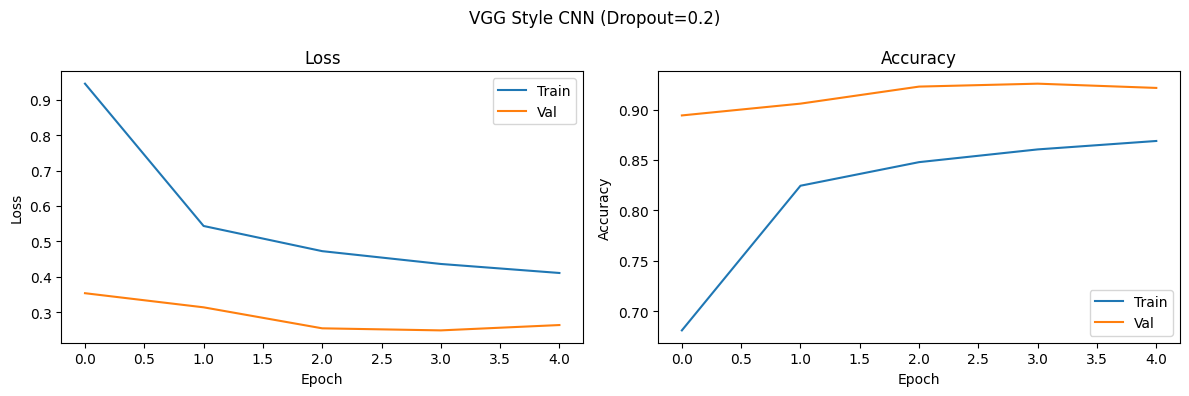

Epoch 1/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 63s 8ms/step - accuracy: 0.6348 - loss: 1.0686 - val_accuracy: 0.8991 - val_loss: 0.3395
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 61s 8ms/step - accuracy: 0.7913 - loss: 0.6419 - val_accuracy: 0.8991 - val_loss: 0.3328
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 63s 8ms/step - accuracy: 0.8172 - loss: 0.5682 - val_accuracy: 0.9238 - val_loss: 0.2531
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 69s 9ms/step - accuracy: 0.8316 - loss: 0.5239 - val_accuracy: 0.9233 - val_loss: 0.2542
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 67s 9ms/step - accuracy: 0.8406 - loss: 0.5007 - val_accuracy: 0.9214 - val_loss: 0.2605
VGG Style CNN (Dropout=0.3) Accuracy: 92.14%


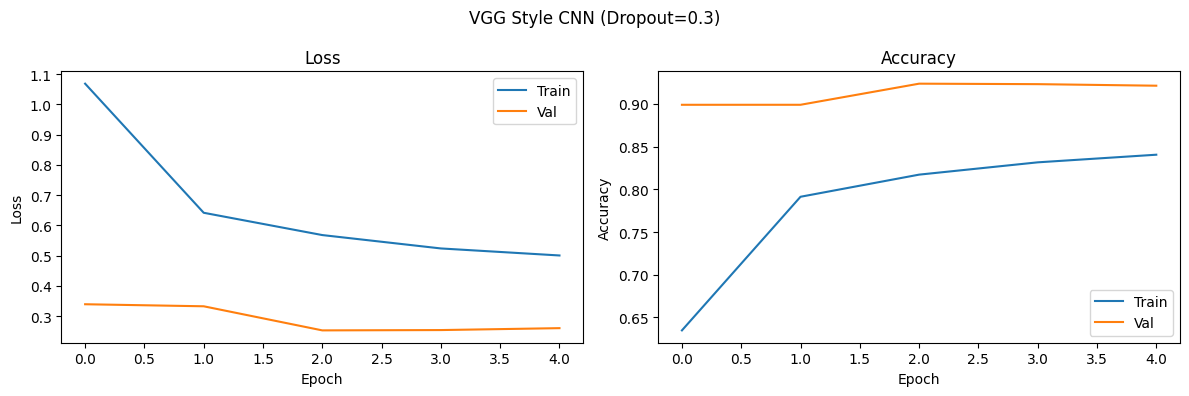

In [148]:
# VGG style con tuning
for dropout in dropoutOptions:
    modelName = f"VGG Style CNN (Dropout={dropout})"
    model = buildVggStyleCNN(dropoutRate=dropout)
    acc = trainAndEvaluate(model, train_ds, val_ds, epochs=epochs, modelName=modelName)
    results.append((modelName, acc))
    modelsDict[modelName] = model

In [ ]:
# DL simple
modelName = "Simple Dense NN"
model3 = buildSimpleDenseModel()
acc3 = trainAndEvaluate(model3, train_ds, val_ds, epochs=epochs, modelName=modelName)
results.append((modelName, acc3))
modelsDict[modelName] = model3

In [ ]:
svmModel = runSvmModelPipeline(train_ds, results, epochs=epochs)
modelsDict["SVM Model"] = svmModel

In [105]:
print("--- Resumen resultados ---")
for name, acc in results:
    print(f"{name}: {acc*100:.2f}%")

bestModel = max(results, key=lambda x: x[1])
print(f"\nMejor modelo: {bestModel[0]} con precisión {bestModel[1]*100:.2f}%")

--- Resumen resultados ---
VGG Style CNN (Dropout=0.2): 98.10%
VGG Style CNN (Dropout=0.3): 98.51%

Mejor modelo: VGG Style CNN (Dropout=0.3) con precisión 98.51%


## Predicción

In [111]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

In [149]:
def loadAndPrepareImages(folderPath, imageSize=(28, 28), verbose=True):
    """
    Carga imágenes desde una carpeta, las redimensiona, convierte a RGB y normaliza.
    Retorna:
    - numpy array [N, 28, 28, 3]
    - lista con nombres de archivo
    """
    images = []
    filenames = []

    if verbose:
        print(f"\nCargando imágenes desde: {folderPath}\n")

    for idx, file in enumerate(os.listdir(folderPath)):
        if file.endswith(".png"):
            try:
                imgPath = os.path.join(folderPath, file)
                img = Image.open(imgPath).convert("RGB")
                img = img.resize(imageSize)
                imgArray = np.array(img) / 255.0
                images.append(imgArray)
                filenames.append(file)

                if verbose:
                    print(f"[{idx+1}] Cargada: {file}")
            except Exception as e:
                print(f"\tError con {file}: {e}")

    if verbose:
        print(f"\nTotal de imágenes cargadas: {len(images)}")

    return np.array(images), filenames

In [150]:
def showPredictions(images, filenames, preds, confs, samples=5, verbose=True):
    """
    Muestra imágenes con predicción y confianza. Si samples=-1, muestra todas las imágenes.
    """
    if verbose:
        print("\nResultados de predicción:\n")
        for i in range(len(images)):
            print(f"[{i+1}] Imagen: {filenames[i]}")
            print(f"\t - Predicción: {preds[i]}")
            print(f"\t - Confianza: {confs[i]:.4f}\n")

    # Mostrar todas si samples == -1
    total = len(images) if samples == -1 else min(samples, len(images))

    cols = min(5, total)
    rows = (total + cols - 1) // cols

    plt.figure(figsize=(3 * cols, 3 * rows))
    for i in range(total):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i])
        plt.title(f"{filenames[i]}\nPred: {preds[i]} ({confs[i]:.2f})")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [151]:
print("Modelos disponibles:")
for name in modelsDict:
    print(f" - {name}")

Modelos disponibles:
 - VGG Style CNN (Dropout=0.2)
 - VGG Style CNN (Dropout=0.3)



Cargando imágenes desde: ./test

[1] Cargada: 0.0.png
[2] Cargada: 0.1.png
[3] Cargada: 0.2.png
[4] Cargada: 0.3.png
[5] Cargada: 0.4.png
[6] Cargada: 0.5.png
[7] Cargada: 0.6.png
[8] Cargada: 0.7.png
[9] Cargada: 0.8.png
[10] Cargada: 0.9.png
[11] Cargada: 1.0.png
[12] Cargada: 1.1.png

Total de imágenes cargadas: 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Resultados de predicción:

[1] Imagen: 0.0.png
	 - Predicción: 9
	 - Confianza: 0.9836

[2] Imagen: 0.1.png
	 - Predicción: 4
	 - Confianza: 0.9391

[3] Imagen: 0.2.png
	 - Predicción: 8
	 - Confianza: 0.9895

[4] Imagen: 0.3.png
	 - Predicción: 7
	 - Confianza: 1.0000

[5] Imagen: 0.4.png
	 - Predicción: 2
	 - Confianza: 1.0000

[6] Imagen: 0.5.png
	 - Predicción: 1
	 - Confianza: 1.0000

[7] Imagen: 0.6.png
	 - Predicción: 6
	 - Confianza: 0.9956

[8] Imagen: 0.7.png
	 - Predicción: 5
	 - Confianza: 1.0000

[9] Imagen: 0.8.png
	 - Predicción: 0
	 - Confianza: 1.0000

[10] Imagen: 0.9.png
	 - Predicción: 3
	 - Confianza: 0.9999

[1

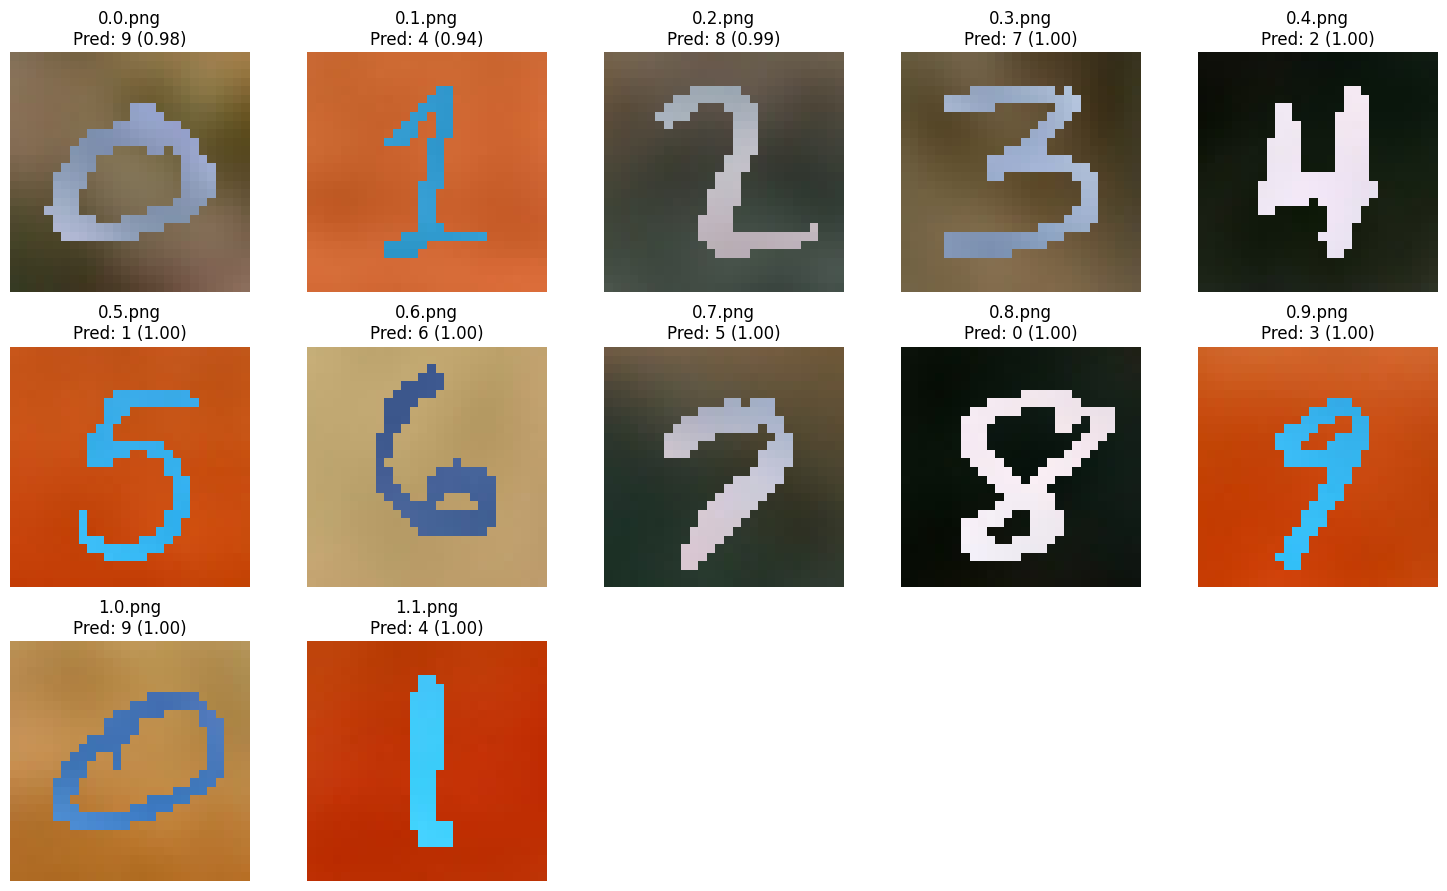

In [152]:
bestModel = modelsDict["VGG Style CNN (Dropout=0.2)"]
images, filenames = loadAndPrepareImages("./test", verbose=True)
preds = bestModel.predict(images)
predClasses = np.argmax(preds, axis=1)
confs = np.max(preds, axis=1)
showPredictions(images, filenames, predClasses, confs, samples=-1, verbose=True)

## Guardando modelos

In [153]:
import os
import pickle
from tensorflow.keras.models import save_model
from tensorflow.keras.models import load_model

SAVE_MODELS = True
LOAD_MODELS = True
USE_LOADED_MODELS = False

In [155]:
def saveModelsToDisk(modelsDict, saveDir="./models"):
    os.makedirs(saveDir, exist_ok=True)

    for name, model in modelsDict.items():
        filename = name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("=", "").replace(".", "")
        filepath = os.path.join(saveDir, f"{filename}")

        if "svm" in filename:
            filepath += ".pkl"
            print(f"Guardando modelo '{name}' como Pickle en {filepath}")
            with open(filepath, "wb") as f:
                pickle.dump(model, f)
        else:
            filepath += ".keras"
            print(f"Guardando modelo '{name}' como Keras en {filepath}")
            model.save(filepath)

    print(f"\nTodos los modelos guardados en: {saveDir}")

In [156]:
if SAVE_MODELS:
    saveModelsToDisk(modelsDict)

Guardando modelo 'VGG Style CNN (Dropout=0.2)' como Keras en ./models\vgg_style_cnn_dropout02.keras
Guardando modelo 'VGG Style CNN (Dropout=0.3)' como Keras en ./models\vgg_style_cnn_dropout03.keras

Todos los modelos guardados en: ./models


In [138]:
def loadModelsFromDisk(loadDir="./models"):
    """
    Carga todos los modelos guardados en la carpeta indicada.
    Retorna un diccionario con nombre legible → modelo cargado.
    """
    modelsDict = {}

    for file in os.listdir(loadDir):
        filepath = os.path.join(loadDir, file)

        # Extraer nombre legible (reverso de cómo lo guardaste)
        modelName = file.replace("_", " ").replace(".keras", "").replace(".pkl", "")
        modelName = modelName.title()

        if file.endswith(".keras"):
            print(f"Cargando modelo Keras desde {filepath}")
            model = load_model(filepath)
        elif file.endswith(".pkl"):
            print(f"Cargando modelo SVM desde {filepath}")
            with open(filepath, "rb") as f:
                model = pickle.load(f)
        else:
            print(f"Archivo no reconocido: {file}")
            continue

        modelsDict[modelName] = model

    print(f"\nModelos cargados: {len(modelsDict)}")
    return modelsDict

In [157]:
if LOAD_MODELS:
    modelsDict = loadModelsFromDisk()
    print("Modelos disponibles:")
    for name in modelsDict:
        print(f" - {name}")
    USE_LOADED_MODELS = True

Cargando modelo Keras desde ./models\simple_cnn.keras
Cargando modelo Keras desde ./models\simple_dense_nn.keras
Cargando modelo SVM desde ./models\svm_model.pkl
Cargando modelo Keras desde ./models\vgg_style_cnn_dropout02.keras
Cargando modelo Keras desde ./models\vgg_style_cnn_dropout03.keras

Modelos cargados: 5
Modelos disponibles:
 - Simple Cnn
 - Simple Dense Nn
 - Svm Model
 - Vgg Style Cnn Dropout02
 - Vgg Style Cnn Dropout03



Cargando imágenes desde: ./test

[1] Cargada: 0.0.png
[2] Cargada: 0.1.png
[3] Cargada: 0.2.png
[4] Cargada: 0.3.png
[5] Cargada: 0.4.png
[6] Cargada: 0.5.png
[7] Cargada: 0.6.png
[8] Cargada: 0.7.png
[9] Cargada: 0.8.png
[10] Cargada: 0.9.png
[11] Cargada: 1.0.png
[12] Cargada: 1.1.png

Total de imágenes cargadas: 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Resultados de predicción:

[1] Imagen: 0.0.png
	 - Predicción: 9
	 - Confianza: 0.9836

[2] Imagen: 0.1.png
	 - Predicción: 4
	 - Confianza: 0.9391

[3] Imagen: 0.2.png
	 - Predicción: 8
	 - Confianza: 0.9895

[4] Imagen: 0.3.png
	 - Predicción: 7
	 - Confianza: 1.0000

[5] Imagen: 0.4.png
	 - Predicción: 2
	 - Confianza: 1.0000

[6] Imagen: 0.5.png
	 - Predicción: 1
	 - Confianza: 1.0000

[7] Imagen: 0.6.png
	 - Predicción: 6
	 - Confianza: 0.9956

[8] Imagen: 0.7.png
	 - Predicción: 5
	 - Confianza: 1.0000

[9] Imagen: 0.8.png
	 - Predicción: 0
	 - Confianza: 1.0000

[10] Imagen: 0.9.png
	 - Predicción: 3
	 - Confianza: 0.9999

[1

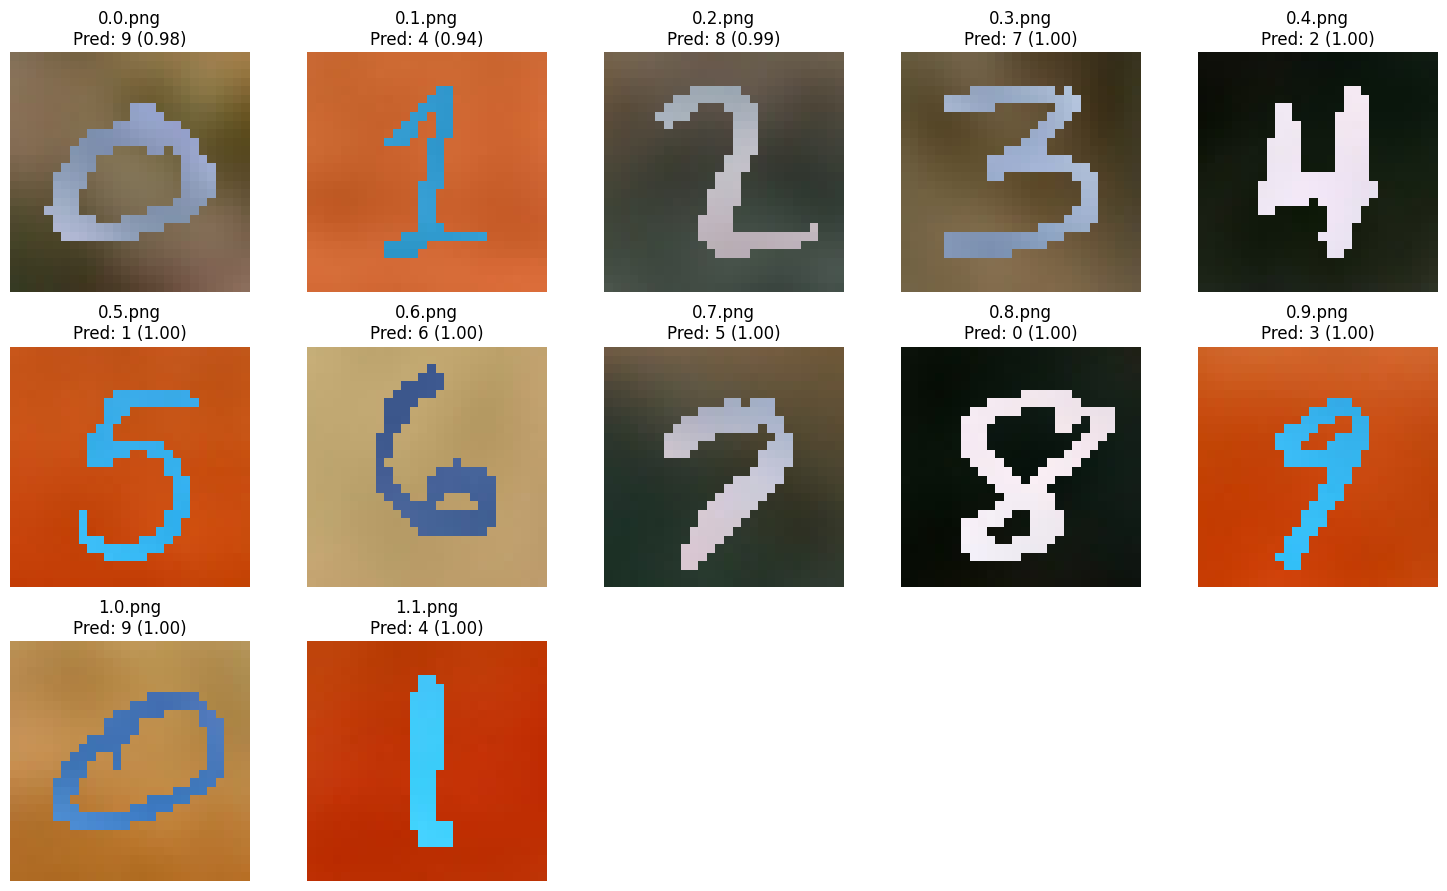

In [159]:
if USE_LOADED_MODELS:
    bestModel = modelsDict["Vgg Style Cnn Dropout02"]
    images, filenames = loadAndPrepareImages("./test", verbose=True)
    preds = bestModel.predict(images)
    predClasses = np.argmax(preds, axis=1)
    confs = np.max(preds, axis=1)
    showPredictions(images, filenames, predClasses, confs, samples=-1, verbose=True)

In [160]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def compareImagesInFolder(folder="./compare"):
    """
    Compara dos imágenes en el folder especificado.
    Muestra dimensiones, tamaño, estadísticas y una visualización.
    """
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if len(files) != 2:
        print(f"⚠️ Se esperaban exactamente 2 imágenes en {folder}, pero se encontraron {len(files)}.")
        return

    img1_path = os.path.join(folder, files[0])
    img2_path = os.path.join(folder, files[1])

    img1 = Image.open(img1_path)
    img2 = Image.open(img2_path)

    arr1 = np.array(img1)
    arr2 = np.array(img2)

    print(f"\n🖼️ Comparando: {files[0]} vs {files[1]}")
    print("-" * 50)

    # Tamaño en bytes
    size1 = os.path.getsize(img1_path)
    size2 = os.path.getsize(img2_path)

    def get_stats(arr):
        return {
            "Shape": arr.shape,
            "Min": arr.min(),
            "Max": arr.max(),
            "Mean": arr.mean()
        }

    stats1 = get_stats(arr1)
    stats2 = get_stats(arr2)

    print(f"{files[0]}:")
    print(f" - Dimensiones: {stats1['Shape']}")
    print(f" - Tamaño en disco: {size1 / 1024:.2f} KB")
    print(f" - Intensidad [min-max]: {stats1['Min']} - {stats1['Max']}")
    print(f" - Promedio de píxeles: {stats1['Mean']:.2f}\n")

    print(f"{files[1]}:")
    print(f" - Dimensiones: {stats2['Shape']}")
    print(f" - Tamaño en disco: {size2 / 1024:.2f} KB")
    print(f" - Intensidad [min-max]: {stats2['Min']} - {stats2['Max']}")
    print(f" - Promedio de píxeles: {stats2['Mean']:.2f}")

    # Mostrar imágenes lado a lado
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img1)
    plt.title(files[0])
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2)
    plt.title(files[1])
    plt.axis("off")

    plt.tight_layout()
    plt.show()



🖼️ Comparando: 0.0 copy.png vs 0.0.png
--------------------------------------------------
0.0 copy.png:
 - Dimensiones: (28, 28, 3)
 - Tamaño en disco: 1.23 KB
 - Intensidad [min-max]: 28 - 211
 - Promedio de píxeles: 104.76

0.0.png:
 - Dimensiones: (28, 28, 3)
 - Tamaño en disco: 2.21 KB
 - Intensidad [min-max]: 0 - 255
 - Promedio de píxeles: 143.52


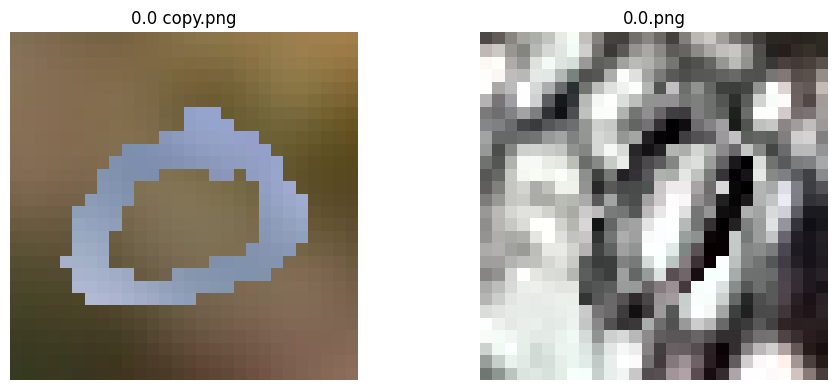

In [161]:
compareImagesInFolder("./compare")


In [164]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[]
